In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded=files.upload()

Saving car evaluation_with.csv to car evaluation_with.csv


In [3]:
df = pd.read_csv("/content/car evaluation_with.csv")

In [4]:
df.shape

(1726, 7)

In [5]:
df.columns

Index(['vhigh', 'vhigh.1', '2', '2.1', 'small', 'med', 'unacc'], dtype='object')

In [6]:
df.isnull().sum()

,0
vhigh,0
vhigh.1,0
2,0
2.1,0
small,0
med,0
unacc,0


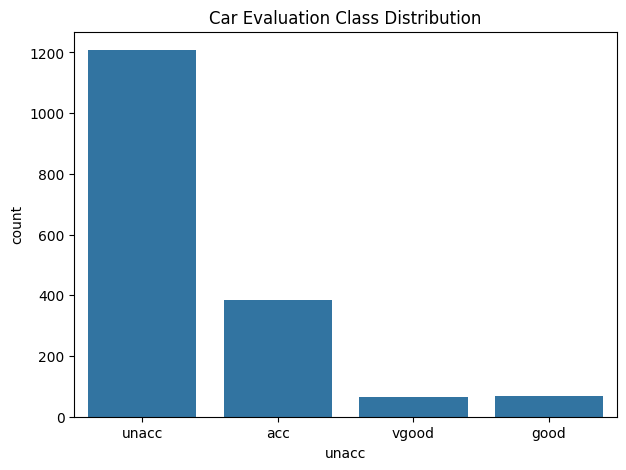

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="unacc"
)

plt.title("Car Evaluation Class Distribution")

plt.show()

In [10]:
df_encoded=df.copy()


encoder={}


for col in df_encoded.columns:

    le=LabelEncoder()

    df_encoded[col]=le.fit_transform(
        df_encoded[col]
    )

    encoder[col]=le


df_encoded.head()

,vhigh,vhigh.1,2,2.1,small,med,unacc
0,3,3,0,0,2,0,2
1,3,3,0,0,1,1,2
2,3,3,0,0,1,2,2
3,3,3,0,0,1,0,2
4,3,3,0,0,0,1,2


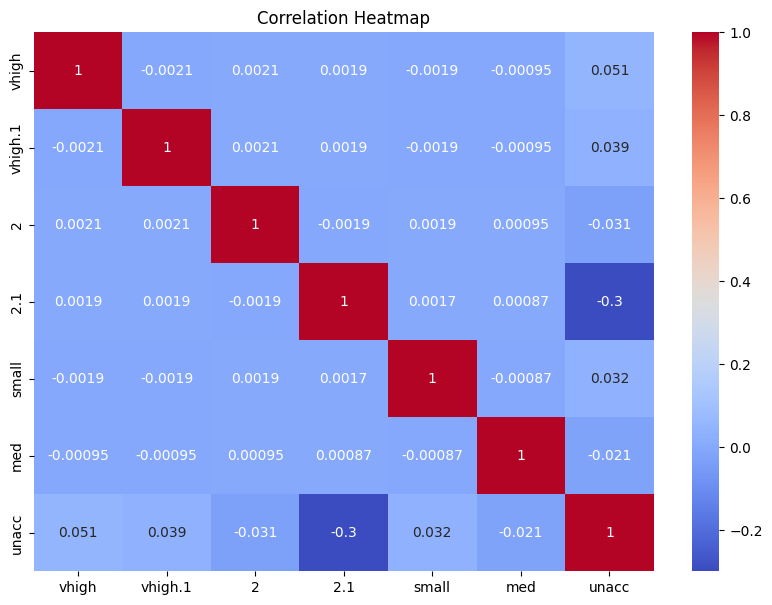

In [11]:
plt.figure(figsize=(10,7))


sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm"
)


plt.title(
    "Correlation Heatmap"
)

plt.show()

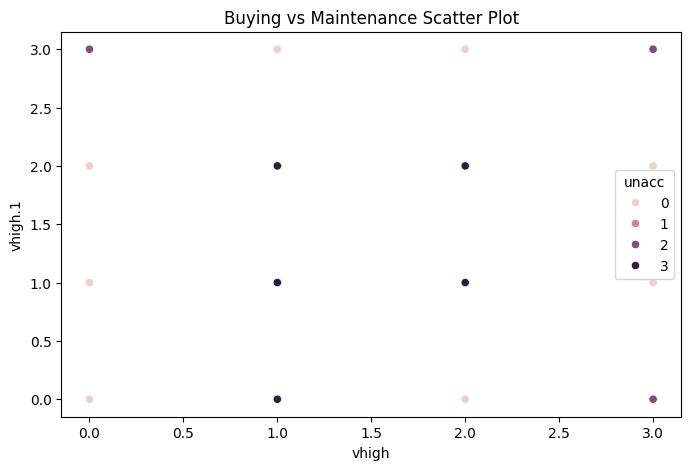

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(

data=df_encoded,

x="vhigh",

y="vhigh.1",

hue="unacc"

)


plt.title(
"Buying vs Maintenance Scatter Plot"
)


plt.show()

In [15]:
X=df_encoded.drop(
    "unacc",
    axis=1
)

y=df_encoded["unacc"]


X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


print(X_train.shape)

print(X_test.shape)

(1380, 6)
(346, 6)


In [16]:
cart=DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)


cart.fit(
    X_train,
    y_train
)


cart_pred=cart.predict(
    X_test
)


cart_accuracy=accuracy_score(
    y_test,
    cart_pred
)


print(
"CART Accuracy:",
cart_accuracy
)

CART Accuracy: 0.9855491329479769


In [17]:
id3=DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)


id3.fit(
    X_train,
    y_train
)


id3_pred=id3.predict(
    X_test
)


id3_accuracy=accuracy_score(
    y_test,
    id3_pred
)


print(
"ID3 Accuracy:",
id3_accuracy
)

ID3 Accuracy: 0.9855491329479769


In [18]:
c45=DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)


c45.fit(
    X_train,
    y_train
)


c45_pred=c45.predict(
    X_test
)


c45_accuracy=accuracy_score(
    y_test,
    c45_pred
)


print(
"C4.5 Accuracy:",
c45_accuracy
)

C4.5 Accuracy: 0.9855491329479769


In [19]:
parameters={

"criterion":[
"gini",
"entropy"
],

"max_depth":[
None,
5,
10,
15,
20
],

"min_samples_split":[
2,
5,
10
],

"min_samples_leaf":[
1,
2,
4
]

}



grid=GridSearchCV(

DecisionTreeClassifier(
random_state=42
),

parameters,

cv=5,

scoring="accuracy",

n_jobs=-1

)



grid.fit(
X_train,
y_train
)



best_model=grid.best_estimator_



print(
grid.best_params_
)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [20]:
best_pred=best_model.predict(
    X_test
)


best_accuracy=accuracy_score(
    y_test,
    best_pred
)


print(
"Best Accuracy:",
best_accuracy
)

Best Accuracy: 0.9855491329479769


,Model,Accuracy
0,CART,0.985549
1,ID3,0.985549
2,C4.5,0.985549
3,Tuned Tree,0.985549


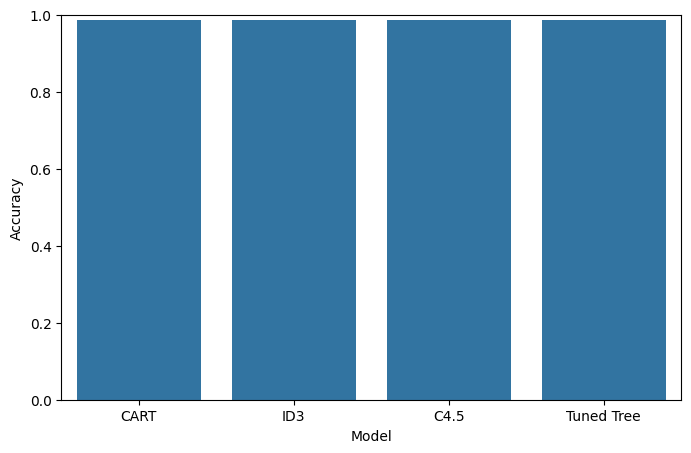

In [21]:
results=pd.DataFrame({

"Model":[
"CART",
"ID3",
"C4.5",
"Tuned Tree"
],


"Accuracy":[

cart_accuracy,

id3_accuracy,

c45_accuracy,

best_accuracy

]

})


display(results)



plt.figure(figsize=(8,5))


sns.barplot(
data=results,
x="Model",
y="Accuracy"
)


plt.ylim(0,1)

plt.show()

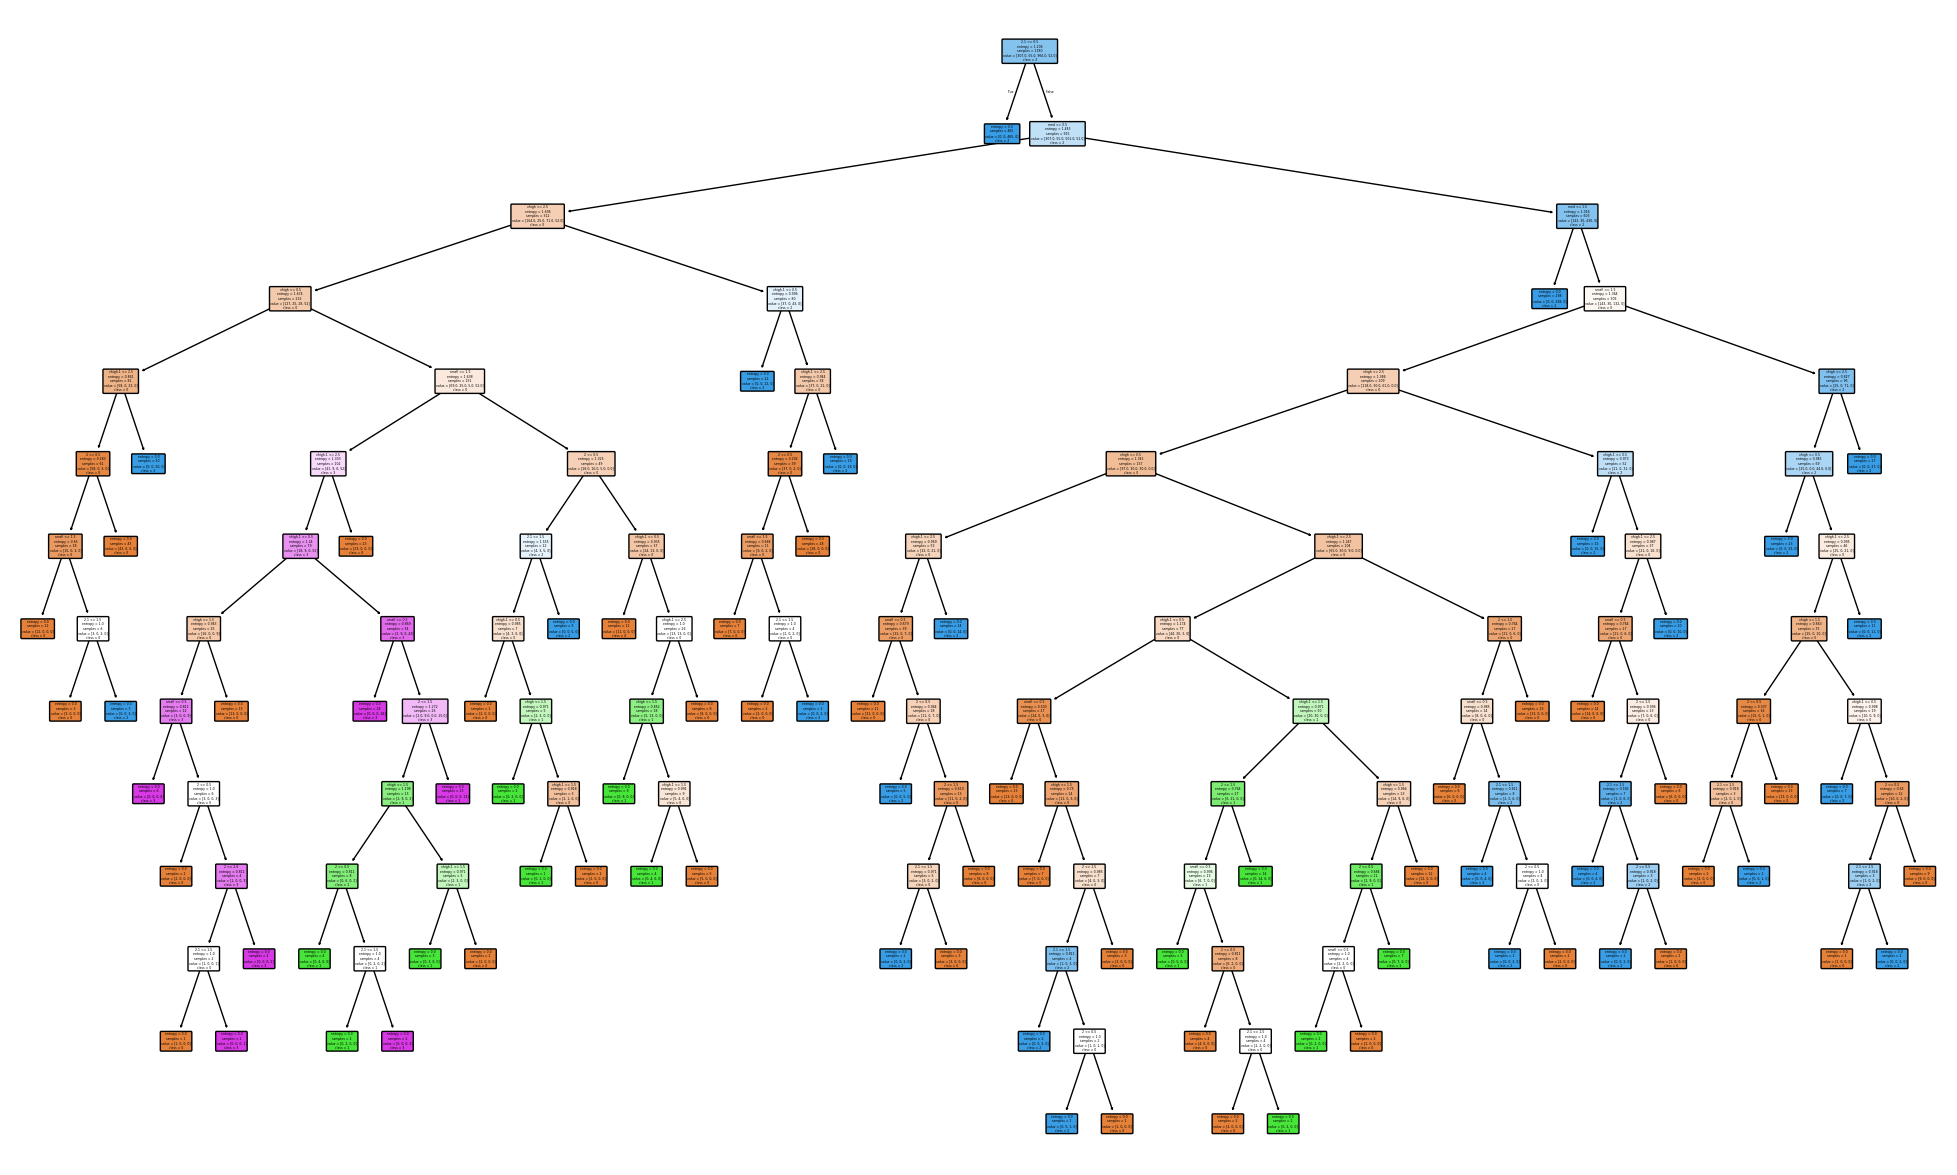

In [22]:
plt.figure(
    figsize=(25,15)
)


plot_tree(

best_model,

feature_names=X.columns,

class_names=[
str(i)
for i in sorted(y.unique())
],

filled=True,

rounded=True

)


plt.show()

In [23]:
rules=export_text(
    best_model,
    feature_names=list(X.columns)
)

print(rules)

|--- 2.1 <= 0.50
|   |--- class: 2
|--- 2.1 >  0.50
|   |--- med <= 0.50
|   |   |--- vhigh <= 2.50
|   |   |   |--- vhigh <= 0.50
|   |   |   |   |--- vhigh.1 <= 2.50
|   |   |   |   |   |--- 2 <= 0.50
|   |   |   |   |   |   |--- small <= 1.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- small >  1.50
|   |   |   |   |   |   |   |--- 2.1 <= 1.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- 2.1 >  1.50
|   |   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- 2 >  0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- vhigh.1 >  2.50
|   |   |   |   |   |--- class: 2
|   |   |   |--- vhigh >  0.50
|   |   |   |   |--- small <= 1.50
|   |   |   |   |   |--- vhigh.1 <= 2.50
|   |   |   |   |   |   |--- vhigh.1 <= 0.50
|   |   |   |   |   |   |   |--- vhigh <= 1.50
|   |   |   |   |   |   |   |   |--- small <= 0.50
|   |   |   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |   |   |   |--- small 